In [1]:
import pandas as pd
import requests

# URL da API para os dados KOI
API_URL_KOI = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=json"

print("🚀 Buscando dados da API da NASA (Kepler Objects of Interest)...")

try:
    # Faz a requisição para a API
    response_koi = requests.get(API_URL_KOI)
    response_koi.raise_for_status() # Verifica se a requisição foi bem-sucedida

    # Converte a resposta JSON em um DataFrame
    print("✅ Dados KOI recebidos! Convertendo para DataFrame...")
    data_koi = response_koi.json()
    df_koi = pd.DataFrame(data_koi)

    print(f"🎉 Sucesso! DataFrame 'df_koi' criado com {df_koi.shape[0]} linhas.")
    
except requests.exceptions.RequestException as e:
    print(f"❌ Erro ao buscar dados KOI: {e}")

# Verificando as primeiras linhas (opcional)
# print(df_koi.head())

🚀 Buscando dados da API da NASA (Kepler Objects of Interest)...
✅ Dados KOI recebidos! Convertendo para DataFrame...
✅ Dados KOI recebidos! Convertendo para DataFrame...
🎉 Sucesso! DataFrame 'df_koi' criado com 9564 linhas.
🎉 Sucesso! DataFrame 'df_koi' criado com 9564 linhas.


Carrega dados do TOI

In [2]:
import pandas as pd
import requests

# URL da API para os dados TOI
API_URL_TOI = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+toi&format=json"

print("🚀 Buscando dados da API da NASA (TESS Objects of Interest)...")

try:
    # Faz a requisição para a API
    response_toi = requests.get(API_URL_TOI)
    response_toi.raise_for_status() # Verifica se a requisição foi bem-sucedida

    # Converte a resposta JSON em um DataFrame
    print("✅ Dados TOI recebidos! Convertendo para DataFrame...")
    data_toi = response_toi.json()
    df_toi = pd.DataFrame(data_toi)

    print(f"🎉 Sucesso! DataFrame 'df_toi' criado com {df_toi.shape[0]} linhas.")

except requests.exceptions.RequestException as e:
    print(f"❌ Erro ao buscar dados TOI: {e}")

# Verificando as primeiras linhas (opcional)
# print(df_toi.head())

🚀 Buscando dados da API da NASA (TESS Objects of Interest)...
✅ Dados TOI recebidos! Convertendo para DataFrame...
✅ Dados TOI recebidos! Convertendo para DataFrame...
🎉 Sucesso! DataFrame 'df_toi' criado com 7703 linhas.
🎉 Sucesso! DataFrame 'df_toi' criado com 7703 linhas.


Unificando os Dados KOI e TOI para o Modelo

In [4]:
import pandas as pd
import numpy as np

# Supondo que df_koi e df_toi já foram carregados

# --- 1. Mapeamento CORRIGIDO para preservar os IDs ---
print("⚙️  Processando dados com mapeamento robusto (IDs preservados)...")

# Mapeamento para KOI
map_koi = {
    'koi_disposition': 'target_disposition',
    'koi_period': 'orbital_period',
    'koi_duration': 'transit_duration_hr',
    'koi_depth': 'transit_depth_ppm',
    'koi_prad': 'planet_radius_earth',
    'koi_steff': 'stellar_temp_k',
    'koi_srad': 'stellar_radius_solar',
    'koi_smass': 'stellar_mass_solar',
    'koi_impact': 'impact_parameter',
    'koi_teq': 'equilibrium_temp',
    'koi_model_snr': 'signal_to_noise'
}
# AQUI ESTÁ A CORREÇÃO: Adicionamos ['kepid'] na seleção
df_koi_std = df_koi[['kepid'] + list(map_koi.keys())].rename(columns=map_koi)
target_map_koi = {'CONFIRMED': 1, 'CANDIDATE': 1, 'FALSE POSITIVE': 0}
df_koi_std['target'] = df_koi_std['target_disposition'].map(target_map_koi)
df_koi_std['source'] = 'Kepler'


# Mapeamento para TOI
map_toi = {
    'tfopwg_disp': 'target_disposition',
    'pl_orbper': 'orbital_period',
    'pl_trandurh': 'transit_duration_hr',
    'pl_trandep': 'transit_depth_ppm',
    'pl_rade': 'planet_radius_earth',
    'st_teff': 'stellar_temp_k',
    'st_rad': 'stellar_radius_solar',
    'pl_eqt': 'equilibrium_temp'
}
# AQUI ESTÁ A CORREÇÃO: Adicionamos ['tid'] na seleção
df_toi_std = df_toi[['tid'] + list(map_toi.keys())].rename(columns=map_toi)
target_map_toi = {'KP': 1, 'CP': 1, 'FP': 0}
df_toi_std['target'] = df_toi_std['target_disposition'].map(target_map_toi)
df_toi_std['source'] = 'TESS'

# --- 2. Combinar, Limpar e Fazer Engenharia de Features ---
print("🤝 Combinando os dois DataFrames...")
df_combined = pd.concat([df_koi_std, df_toi_std], ignore_index=True)
df_combined.dropna(subset=['target'], inplace=True)
df_combined['target'] = df_combined['target'].astype(int)
df_combined.drop(columns=['target_disposition'], inplace=True)

print("🛠️  Iniciando a Engenharia de Features...")
df_featured = df_combined.copy()
df_featured['stellar_density'] = df_featured['stellar_mass_solar'] / (df_featured['stellar_radius_solar']**3 + 1e-6)
df_featured['duration_over_period'] = df_featured['transit_duration_hr'] / (df_featured['orbital_period'] * 24 + 1e-6)
df_featured['depth_per_planet_radius'] = df_featured['transit_depth_ppm'] / (df_featured['planet_radius_earth']**2 + 1e-6)
df_featured.replace([np.inf, -np.inf], 0, inplace=True)

print("✅ Processo de preparação completo. IDs 'kepid' e 'tid' foram preservados.")

⚙️  Processando dados com mapeamento robusto (IDs preservados)...
🤝 Combinando os dois DataFrames...
🛠️  Iniciando a Engenharia de Features...
✅ Processo de preparação completo. IDs 'kepid' e 'tid' foram preservados.


🚀 Iniciando a busca pelos melhores hiperparâmetros com GridSearchCV...
💪 Treinando múltiplos modelos... Por favor, aguarde.
Fitting 3 folds for each of 18 candidates, totalling 54 fits

✅ Busca concluída!

--- Melhores Parâmetros Encontrados ---
{'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300}

Melhor Acurácia (durante a busca): 0.8341

--- Avaliando o melhor modelo no conjunto de teste separado ---

Acurácia Final no Teste: 0.8351

Relatório de Classificação Final:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1811
           1       0.83      0.85      0.84      1798

    accuracy                           0.84      3609
   macro avg       0.84      0.84      0.84      3609
weighted avg       0.84      0.84      0.84      3609


Matriz de Confusão Final:

✅ Busca concluída!

--- Melhores Parâmetros Encontrados ---
{'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300}

Melhor Acurácia (durante a busca): 0.834

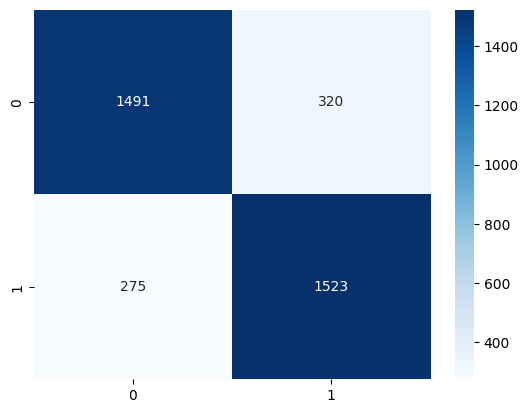

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

print("🚀 Iniciando a busca pelos melhores hiperparâmetros com GridSearchCV...")

# --- 1. Definir o "Grid" de parâmetros que queremos testar ---
# Um dicionário com os parâmetros e os valores que vamos experimentar
param_grid = {
    'n_estimators': [100, 200, 300],         # Número de "árvores" no modelo
    'max_depth': [3, 5, 7],                  # Profundidade máxima de cada árvore
    'learning_rate': [0.05, 0.1]             # Taxa de aprendizado (quão rápido o modelo aprende)
}

# --- 2. Preparar os dados (exatamente como antes) ---
features = [
    'orbital_period', 'transit_duration_hr', 'transit_depth_ppm', 
    'planet_radius_earth', 'stellar_temp_k', 'stellar_radius_solar',
    'stellar_mass_solar', 'impact_parameter', 'equilibrium_temp',
    'stellar_density', 'duration_over_period', 'depth_per_planet_radius'
]
X = df_featured[features].fillna(0)
y = df_featured['target']

# Vamos dividir os dados ANTES para ter um conjunto de teste real para o modelo final
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- 3. Configurar e Rodar o GridSearchCV ---
# O GridSearchCV usará o X_train e y_train para fazer sua busca interna
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,          # Validação cruzada com 3 divisões
    n_jobs=-1,     # Usa todos os núcleos do seu processador
    verbose=2      # Mostra o progresso
)

print("💪 Treinando múltiplos modelos... Por favor, aguarde.")
grid_search.fit(X_train, y_train)

print("\n✅ Busca concluída!")

# --- 4. Exibir os melhores resultados encontrados ---
print("\n--- Melhores Parâmetros Encontrados ---")
print(grid_search.best_params_)

print(f"\nMelhor Acurácia (durante a busca): {grid_search.best_score_:.4f}")

# --- 5. Avaliar o MELHOR modelo no conjunto de teste ---
print("\n--- Avaliando o melhor modelo no conjunto de teste separado ---")
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nAcurácia Final no Teste: {accuracy_score(y_test, y_pred):.4f}")
print("\nRelatório de Classificação Final:")
print(classification_report(y_test, y_pred))
print("\nMatriz de Confusão Final:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

Treinando e Avaliando o Modelo XGBoost

🚀 Iniciando o treinamento do modelo XGBoost OTIMIZADO...
Dados divididos: 8419 para treino, 3609 para teste.
💪 Treinando o modelo final... Isso será rápido.
✅ Modelo final treinado com sucesso!

--- Resultados da Avaliação do Modelo Otimizado ---
Acurácia: 0.8365

Relatório de Classificação:
                    precision    recall  f1-score   support

Falso Positivo (0)       0.84      0.83      0.84      1811
       Planeta (1)       0.83      0.84      0.84      1798

          accuracy                           0.84      3609
         macro avg       0.84      0.84      0.84      3609
      weighted avg       0.84      0.84      0.84      3609


Matriz de Confusão:
✅ Modelo final treinado com sucesso!

--- Resultados da Avaliação do Modelo Otimizado ---
Acurácia: 0.8365

Relatório de Classificação:
                    precision    recall  f1-score   support

Falso Positivo (0)       0.84      0.83      0.84      1811
       Planeta (1)       0.83      0.84      0.84      1798

     

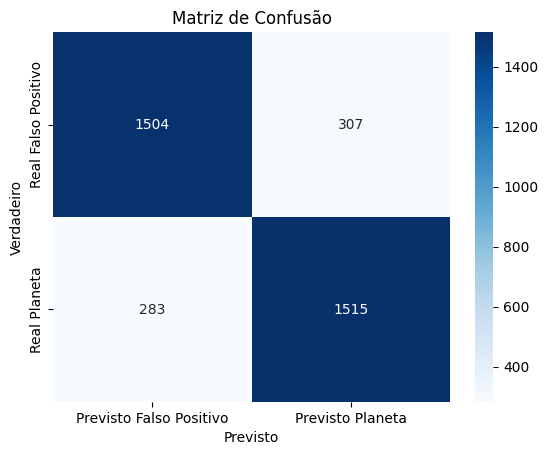

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Iniciando o treinamento do modelo XGBoost OTIMIZADO...")

# --- Passo 1: Separar Features (X) e Alvo (y) ---
features = [
    'orbital_period', 'transit_duration_hr', 'transit_depth_ppm', 
    'planet_radius_earth', 'stellar_temp_k', 'stellar_radius_solar',
    'stellar_mass_solar', 'impact_parameter', 'equilibrium_temp',
    'stellar_density', 'duration_over_period', 'depth_per_planet_radius',
    'signal_to_noise'  # <<< NOVA FEATURE ADICIONADA AQUI
]
X = df_featured[features]
y = df_featured['target']

# --- Passo 2: Lidar com valores ausentes ---
X = X.fillna(0)

# --- Passo 3: Dividir dados em Treino e Teste ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,
    random_state=42,
    stratify=y
)
print(f"Dados divididos: {X_train.shape[0]} para treino, {X_test.shape[0]} para teste.")

# --- Passo 4: Treinar o Modelo XGBoost OTIMIZADO ---
# Instanciamos o classificador com os MELHORES PARÂMETROS encontrados pelo GridSearchCV
model = xgb.XGBClassifier(
    objective='binary:logistic', 
    eval_metric='logloss',
    random_state=42,
    # --- PARÂMETROS OTIMIZADOS ---
    learning_rate=0.05,
    max_depth=7,
    n_estimators=300
)

print("💪 Treinando o modelo final... Isso será rápido.")
model.fit(X_train, y_train)
print("✅ Modelo final treinado com sucesso!")

# --- Passo 5: Avaliar o Modelo Final ---
print("\n--- Resultados da Avaliação do Modelo Otimizado ---")
y_pred = model.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Falso Positivo (0)', 'Planeta (1)']))
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto Falso Positivo', 'Previsto Planeta'], 
            yticklabels=['Real Falso Positivo', 'Real Planeta'])
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

In [7]:
import pandas as pd

# Supondo que 'df_featured' é o seu DataFrame final, 
# contendo as colunas 'source', 'kepid', e 'tid'.

print("Gerando listas de alvos para a equipe ExoMiner...")

# --- 1. Gerar a lista de IDs do Kepler ---
kepler_df = df_featured[df_featured['source'] == 'Kepler']
kepler_ids = kepler_df['kepid'].dropna().unique().astype(int)

kepler_ids_df = pd.DataFrame(kepler_ids, columns=['kepid'])
kepler_ids_df.to_csv('kepler_ids_para_predicao.csv', index=False)

print(f"✅ Arquivo 'kepler_ids_para_predicao.csv' gerado com {len(kepler_ids_df)} alvos únicos do Kepler.")


# --- 2. Gerar a lista de IDs do TESS ---
tess_df = df_featured[df_featured['source'] == 'TESS']
# A coluna de ID do TESS pode ter vindo como 'tid' do nosso processamento
tess_ids = tess_df['tid'].dropna().unique().astype(int)

# O modelo ExoMiner do Márcio espera a coluna como 'tic_id', então já vamos renomear.
tess_ids_df = pd.DataFrame(tess_ids, columns=['tic_id'])
tess_ids_df.to_csv('tess_ids_para_predicao.csv', index=False)

print(f"✅ Arquivo 'tess_ids_para_predicao.csv' gerado com {len(tess_ids_df)} alvos únicos do TESS.")

Gerando listas de alvos para a equipe ExoMiner...
✅ Arquivo 'kepler_ids_para_predicao.csv' gerado com 8214 alvos únicos do Kepler.
✅ Arquivo 'tess_ids_para_predicao.csv' gerado com 2339 alvos únicos do TESS.


In [12]:
import joblib

# Supondo que 'best_model' é o seu modelo final do grid_search
joblib.dump(model, 'xgboost_model.pkl') 
print("Modelo XGBoost salvo com sucesso em 'xgboost_model.pkl'")

Modelo XGBoost salvo com sucesso em 'xgboost_model.pkl'


🚀 Starting Task 1.3: Training the Stacking Meta-Model using 'exominer_predictions_reference.csv'...
   - Generating predictions from Optimized XGBoost...
   - Loading ExoMiner predictions from: exominer_predictions_reference.csv...
   - Merging scores to create the meta-model dataset...
   - Training the Meta-Model (Logistic Regression)...

--- Final Stacking Model Evaluation ---
Final Stacking Accuracy: 0.9444

Stacking Classification Report:
                    precision    recall  f1-score   support

False Positive (0)       0.90      0.69      0.78       144
        Planet (1)       0.95      0.99      0.97       845

          accuracy                           0.94       989
         macro avg       0.93      0.84      0.88       989
      weighted avg       0.94      0.94      0.94       989



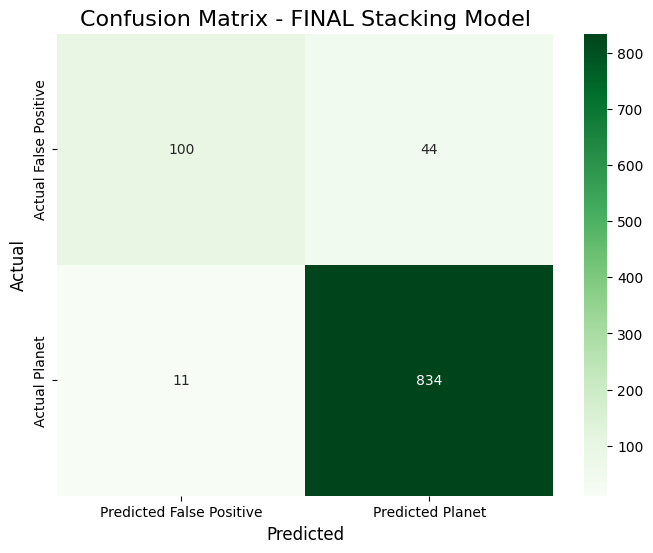

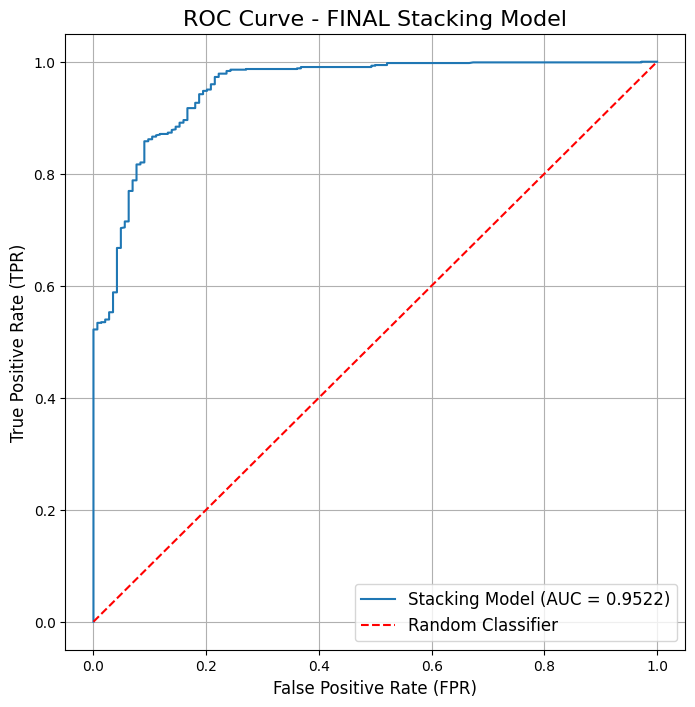


✅ Stacking Meta-Model saved successfully to 'meta_model.pkl'


In [43]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# --- ESCOLHA AQUI QUAL ARQUIVO DE PREDIÇÃO USAR ---
# Mude para o nome do seu arquivo real quando ele estiver pronto (ex: 'exominer_predictions_real.csv')
EXOMINER_PREDICTIONS_FILE = 'exominer_predictions_reference.csv'
# ----------------------------------------------------

print(f"🚀 Starting Task 1.3: Training the Stacking Meta-Model using '{EXOMINER_PREDICTIONS_FILE}'...")

# --- Step 1: Generate predictions from our Optimized XGBoost ---
print("   - Generating predictions from Optimized XGBoost...")
features_xgboost = [
    'orbital_period', 'transit_duration_hr', 'transit_depth_ppm', 
    'planet_radius_earth', 'stellar_temp_k', 'stellar_radius_solar',
    'stellar_mass_solar', 'impact_parameter', 'equilibrium_temp',
    'stellar_density', 'duration_over_period', 'depth_per_planet_radius',
    'signal_to_noise'
]
X_full = df_featured[features_xgboost].fillna(0)
xgboost_scores = model.predict_proba(X_full)[:, 1]
xgboost_predictions_df = pd.DataFrame({
    'target_id': df_featured['target_id'].astype(int),
    'xgboost_score': xgboost_scores
})

# --- Step 2: Load predictions from ExoMiner (Real or Mock) ---
print(f"   - Loading ExoMiner predictions from: {EXOMINER_PREDICTIONS_FILE}...")
try:
    exominer_predictions_df = pd.read_csv(EXOMINER_PREDICTIONS_FILE)
except FileNotFoundError:
    print(f"❌ ERROR: Prediction file not found at '{EXOMINER_PREDICTIONS_FILE}'.")
    print("Please generate the mock file by running the cell above, or provide a file with real predictions.")
    raise

# --- Step 3: Create the Meta-Model Dataset ---
print("   - Merging scores to create the meta-model dataset...")
meta_df = pd.merge(xgboost_predictions_df, exominer_predictions_df, on='target_id')
targets_df = df_featured[['target_id', 'target']].astype({'target_id': int})
meta_df = pd.merge(meta_df, targets_df, on='target_id')
X_meta = meta_df[['xgboost_score', 'exominer_score']]
y_meta = meta_df['target']

# --- Step 4: Train the Meta-Model ---
print("   - Training the Meta-Model (Logistic Regression)...")
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    X_meta, y_meta, test_size=0.3, random_state=42, stratify=y_meta
)
meta_model = LogisticRegression(random_state=42)
meta_model.fit(X_train_meta, y_train_meta)

# --- Step 5: Evaluate the Stacking performance ---
print("\n--- Final Stacking Model Evaluation ---")
y_pred_final = meta_model.predict(X_test_meta)
print(f"Final Stacking Accuracy: {accuracy_score(y_test_meta, y_pred_final):.4f}")
print("\nStacking Classification Report:")
print(classification_report(y_test_meta, y_pred_final, target_names=['False Positive (0)', 'Planet (1)']))

# --- START OF GRAPHING CODE ---

# 1. Stacking Model Confusion Matrix
cm_stacking = confusion_matrix(y_test_meta, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_stacking, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted False Positive', 'Predicted Planet'],
            yticklabels=['Actual False Positive', 'Actual Planet'])
plt.title('Confusion Matrix - FINAL Stacking Model', fontsize=16)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

# 2. Stacking Model ROC Curve
y_proba_stacking = meta_model.predict_proba(X_test_meta)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_meta, y_proba_stacking)
auc_score = roc_auc_score(y_test_meta, y_proba_stacking)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label=f'Stacking Model (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.title('ROC Curve - FINAL Stacking Model', fontsize=16)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(fontsize=12)
plt.grid()
plt.show()
# --- END OF GRAPHING CODE ---

# --- Step 6: Save the Trained Meta-Model ---
joblib.dump(meta_model, 'meta_model.pkl')
print("\n✅ Stacking Meta-Model saved successfully to 'meta_model.pkl'")

In [10]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

print("🚀 Iniciando a Tarefa 1.4: Preparação dos componentes do 'Vizinho Mais Próximo'...")

# O 'meta_df' que criamos na etapa anterior já tem os scores.
# Precisamos juntá-lo com as features originais para a busca.
# Supondo que 'df_featured' tem todas as colunas de features e o 'target_id'.
reference_db = pd.merge(df_featured, meta_df[['target_id', 'exominer_score']], on='target_id')

# 1. Defina as features para a busca (o espaço de similaridade)
features_para_busca = [
    'orbital_period', 'transit_depth_ppm', 'signal_to_noise', 
    'planet_radius_earth', 'stellar_radius_solar'
]

# 2. Crie e salve o Scaler
scaler = StandardScaler()
# Usamos .fillna(0) para garantir que não há valores nulos antes de treinar o scaler
scaler.fit(reference_db[features_para_busca].fillna(0))
joblib.dump(scaler, 'scaler.pkl')
print("   - Scaler salvo com sucesso em 'scaler.pkl'")

# 3. Crie e salve o Buscador (NearestNeighbors)
scaled_reference_features = scaler.transform(reference_db[features_para_busca].fillna(0))
nn_finder = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn_finder.fit(scaled_reference_features)
joblib.dump(nn_finder, 'nn_finder.pkl')
print("   - Buscador de Vizinhos salvo com sucesso em 'nn_finder.pkl'")

# 4. Salve a base de referência completa
reference_db.to_csv('reference_db.csv', index=False)
print("   - Base de referência salva com sucesso em 'reference_db.csv'")

print("\n✅ Componentes do 'Vizinho Mais Próximo' prontos para produção.")

🚀 Iniciando a Tarefa 1.4: Preparação dos componentes do 'Vizinho Mais Próximo'...
   - Scaler salvo com sucesso em 'scaler.pkl'
   - Buscador de Vizinhos salvo com sucesso em 'nn_finder.pkl'
   - Base de referência salva com sucesso em 'reference_db.csv'

✅ Componentes do 'Vizinho Mais Próximo' prontos para produção.


In [11]:
import shap
import joblib

# Supondo que 'model' é o seu modelo XGBoost otimizado e treinado
# e 'X_train' são os dados de treino que você usou.

print("Criando o explicador SHAP...")

# Para modelos baseados em árvore como o XGBoost, usamos o TreeExplainer
# Ele aprende as estruturas internas do modelo para gerar explicações eficientes
explainer = shap.TreeExplainer(model)

# Salva o explicador em um arquivo para uso futuro na API
joblib.dump(explainer, 'shap_explainer.pkl')

print("✅ Explicador SHAP salvo com sucesso em 'shap_explainer.pkl'")

c:\Users\gusta\ExoLens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Criando o explicador SHAP...
✅ Explicador SHAP salvo com sucesso em 'shap_explainer.pkl'


In [42]:
from sklearn.metrics import classification_report

# Pega as probabilidades contínuas do modelo para o conjunto de teste
y_probabilities = meta_model.predict_proba(X_test_meta)[:, 1]

# --- EXPERIMENTE MUDAR O PONTO DE DECISÃO AQUI ---
# Padrão é 0.5. Tente um valor mais alto, como 0.7 ou 0.8
NOVO_PONTO_DE_DECISAO = 0.7
# ----------------------------------------------------

# Cria as novas previsões com base no nosso novo limite
y_pred_ajustado = (y_probabilities >= NOVO_PONTO_DE_DECISAO).astype(int)

print(f"--- Relatório com Ponto de Decisão = {NOVO_PONTO_DE_DECISAO} ---")
print(classification_report(y_test_meta, y_pred_ajustado, target_names=['Falso Positivo (0)', 'Planet (1)']))

--- Relatório com Ponto de Decisão = 0.7 ---
                    precision    recall  f1-score   support

Falso Positivo (0)       0.86      0.78      0.82       144
        Planet (1)       0.96      0.98      0.97       845

          accuracy                           0.95       989
         macro avg       0.91      0.88      0.89       989
      weighted avg       0.95      0.95      0.95       989



In [45]:
import pandas as pd

# Supondo que 'meta_model_hibrido' é o seu meta-modelo final treinado
# Se o nome da variável for outro (ex: meta_model), apenas ajuste.
try:
    model_to_inspect = meta_model
    print("Analisando o Meta-Modelo Híbrido...")
except NameError:
    model_to_inspect = meta_model
    print("Analisando o Meta-Modelo da Simulação 'Perfeita'...")


# Pega os nomes das features que o meta-modelo usou
feature_names = model_to_inspect.feature_names_in_

# Pega os pesos (coeficientes) que o modelo aprendeu para cada feature
weights = model_to_inspect.coef_[0]

# Cria um DataFrame para visualizar os pesos
weights_df = pd.DataFrame({
    'Especialista (Feature)': feature_names,
    'Peso (Coeficiente)': weights
})

weights_df_sorted = weights_df.sort_values(by='Peso (Coeficiente)', ascending=False)

print("\n--- Importância de Cada Especialista para o Meta-Modelo ---")
print(weights_df_sorted.to_string(index=False))

Analisando o Meta-Modelo Híbrido...

--- Importância de Cada Especialista para o Meta-Modelo ---
Especialista (Feature)  Peso (Coeficiente)
         xgboost_score            7.024803
        exominer_score            2.476384


In [46]:
import pandas as pd

print("--- Iniciando Auditoria dos Arquivos de Predição ---")

# 1. Carregar nosso dataset principal (que tem a coluna 'source')
try:
    # Garante que as variáveis necessárias do notebook estão prontas
    nosso_dataset = df_featured[['target_id', 'source']].copy()
    print(f"Nosso dataset completo ('df_featured') tem {len(nosso_dataset)} candidatos.")
    print("Distribuição original:")
    print(nosso_dataset['source'].value_counts())
    print("-" * 30)
except NameError:
    print("ERRO: A variável 'df_featured' não foi encontrada. Rode as células de preparação de dados primeiro.")
    raise

# 2. Carregar o arquivo de predições do ExoMiner que você está usando
try:
    # Use o mesmo nome de arquivo que está no seu script de treinamento
    exominer_preds = pd.read_csv('exominer_predictions_reference.csv')
    print(f"O arquivo do ExoMiner ('exominer_predictions_reference.csv') tem {len(exominer_preds)} predições.")
except FileNotFoundError:
    print("ERRO: 'exominer_predictions_reference.csv' não encontrado na pasta 'notebooks/'.")
    raise

# 3. Fazer o cruzamento (merge) para ver a sobreposição
# Usamos um 'inner join' para ver quantos IDs são comuns a ambos os arquivos
# Isso garante que estamos comparando IDs que existem nos dois lugares
merge_result = pd.merge(nosso_dataset, exominer_preds, on='target_id', how='inner')

print("\n--- RESULTADO DA AUDITORIA ---")
print(f"Foram encontrados {len(merge_result)} candidatos EM COMUM entre nosso dataset e o do ExoMiner.")

# 4. Contar quantos são de cada fonte (Kepler vs TESS)
print("\nDistribuição dos candidatos em comum por fonte:")
contagem_fontes = merge_result['source'].value_counts()

if not contagem_fontes.empty:
    print(contagem_fontes)
else:
    print("Nenhum candidato em comum foi encontrado. Verifique se a coluna 'target_id' está correta em ambos os arquivos.")

print("\n--- CONCLUSÃO DA ANÁLISE ---")

--- Iniciando Auditoria dos Arquivos de Predição ---
Nosso dataset completo ('df_featured') tem 12028 candidatos.
Distribuição original:
source
Kepler    9564
TESS      2464
Name: count, dtype: int64
------------------------------
O arquivo do ExoMiner ('exominer_predictions_reference.csv') tem 11289 predições.

--- RESULTADO DA AUDITORIA ---
Foram encontrados 2181 candidatos EM COMUM entre nosso dataset e o do ExoMiner.

Distribuição dos candidatos em comum por fonte:
source
TESS    2181
Name: count, dtype: int64

--- CONCLUSÃO DA ANÁLISE ---
